# Teil 2 - data_description

In diesem Notebook bearbeite ich **nur Teil 2** der LB. Ich lese den Datensatz ein, suche ein Feld fuer eine spaetere Vorhersage aus, zeige einfache Statistiken, erstelle eine Grafik und skaliere ein Zahlenfeld.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv('Smartphone_Usage_Productivity_Dataset_50000.csv', sep=';')

print('Zeilen:', len(df))
print('Spalten:', df.shape[1])
df.head()

Zeilen: 50000
Spalten: 13


,User_ID,Age,Gender,Occupation,Device_Type,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours
0,U1,58,Male,Professional,Android,1.3,6.7,6,8.8,4,42,1,8.7
1,U2,25,Male,Professional,Android,1.2,1.5,5,6.4,1,51,3,5.1
2,U3,19,Male,Student,iOS,5.3,5.7,5,9.0,4,14,5,6.3
3,U4,35,Female,Business Owner,iOS,5.8,2.5,2,5.7,3,36,6,12.8
4,U5,33,Male,Freelancer,Android,7.9,1.3,4,5.7,3,37,5,9.9


## 2.1 Welches Feld moechte ich vorhersagen?

Ich moechte spaeter das Feld **`Work_Productivity_Score`** vorhersagen. Ich habe dieses Feld gewaehlt, weil es zeigt, wie produktiv eine Person ist. Die anderen Felder wie Alter, Handy-Nutzung, Social Media, Schlaf oder Stress koennten dabei helfen, diesen Wert zu schaetzen.

In [2]:
ziel_feld = 'Work_Productivity_Score'
print('Mein Ziel-Feld ist:', ziel_feld)
df[ziel_feld].head()

Mein Ziel-Feld ist: Work_Productivity_Score


0    6
1    5
2    5
3    2
4    4
Name: Work_Productivity_Score, dtype: int64

## 2.2 Einfache statistische Informationen

Fuer die Zahlenfelder zeige ich Mittelwert, Median, Standardabweichung, Minimum und Maximum. Fuer Textfelder zeige ich den haeufigsten Wert und wie viele verschiedene Werte es gibt.

In [3]:
numerische_statistik = df.describe().T[['mean', '50%', 'std', 'min', 'max']].rename(columns={
    'mean': 'Mittelwert',
    '50%': 'Median',
    'std': 'Standardabweichung',
    'min': 'Minimum',
    'max': 'Maximum'
}).round(2)

numerische_statistik

,Mittelwert,Median,Standardabweichung,Minimum,Maximum
Age,39.03,39.0,12.41,18.0,60.0
Daily_Phone_Hours,6.51,6.5,3.17,1.0,12.0
Social_Media_Hours,4.27,4.3,2.16,0.5,8.0
Work_Productivity_Score,5.50,5.5,2.87,1.0,10.0
Sleep_Hours,6.50,6.5,1.45,4.0,9.0
Stress_Level,5.50,6.0,2.87,1.0,10.0
App_Usage_Count,32.44,32.0,16.12,5.0,60.0
Caffeine_Intake_Cups,3.00,3.0,2.00,0.0,6.0
Weekend_Screen_Time_Hours,8.01,8.0,3.46,2.0,14.0


In [4]:
text_spalten = ['User_ID', 'Gender', 'Occupation', 'Device_Type']
zeilen = []

for spalte in text_spalten:
    zeilen.append({
        'Feld': spalte,
        'Verschiedene_Werte': df[spalte].nunique(),
        'Haeufigster_Wert': df[spalte].mode()[0]
    })

kategoriale_statistik = pd.DataFrame(zeilen)
kategoriale_statistik

,Feld,Verschiedene_Werte,Haeufigster_Wert
0,User_ID,50000,U1
1,Gender,3,Male
2,Occupation,4,Professional
3,Device_Type,2,Android


In [5]:
print('Fehlende Werte pro Spalte:')
df.isna().sum()

Fehlende Werte pro Spalte:


User_ID                      0
Age                          0
Gender                       0
Occupation                   0
Device_Type                  0
Daily_Phone_Hours            0
Social_Media_Hours           0
Work_Productivity_Score      0
Sleep_Hours                  0
Stress_Level                 0
App_Usage_Count              0
Caffeine_Intake_Cups         0
Weekend_Screen_Time_Hours    0
dtype: int64

## 2.3 Eine einfache Grafik

Hier erstelle ich ein Histogramm fuer `Daily_Phone_Hours`. So sieht man, wie sich die taegliche Handy-Nutzung im Datensatz verteilt.

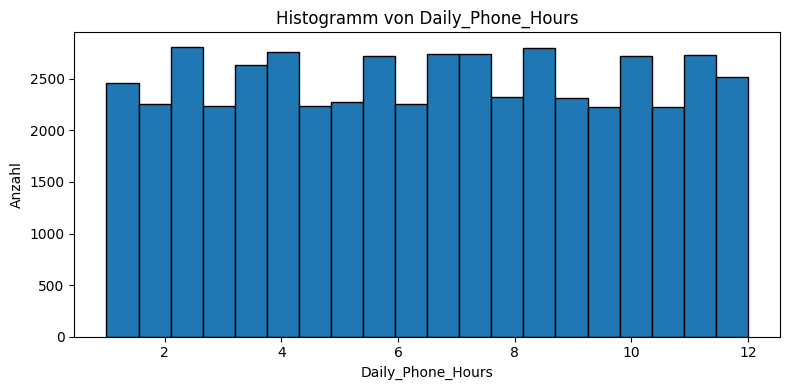

In [6]:
plt.figure(figsize=(8, 4))
plt.hist(df['Daily_Phone_Hours'], bins=20, edgecolor='black')
plt.title('Histogramm von Daily_Phone_Hours')
plt.xlabel('Daily_Phone_Hours')
plt.ylabel('Anzahl')
plt.tight_layout()
plt.show()

## 2.4 Ein Datenfeld skalieren

Ich skaliere das Feld **`Daily_Phone_Hours`** mit dem `MinMaxScaler`. Danach liegen die Werte zwischen **0** und **1**. Das ist einfach zu verstehen und spaeter fuer Machine Learning oft praktisch.

In [7]:
scaler = MinMaxScaler()
df['Daily_Phone_Hours_0_1'] = scaler.fit_transform(df[['Daily_Phone_Hours']])

print('Kleinster skalierter Wert:', df['Daily_Phone_Hours_0_1'].min())
print('Groesster skalierter Wert:', df['Daily_Phone_Hours_0_1'].max())

df[['Daily_Phone_Hours', 'Daily_Phone_Hours_0_1']].head(10)

Kleinster skalierter Wert: 0.0
Groesster skalierter Wert: 0.9999999999999999


,Daily_Phone_Hours,Daily_Phone_Hours_0_1
0,1.3,0.027273
1,1.2,0.018182
2,5.3,0.390909
3,5.8,0.436364
4,7.9,0.627273
5,10.9,0.900000
6,5.6,0.418182
7,8.5,0.681818
8,9.4,0.763636
9,2.8,0.163636


## Kurzes Fazit

Ich habe ein Ziel-Feld fuer die spaetere Vorhersage ausgewaehlt, einfache Statistiken angeschaut, eine Grafik erstellt und ein Feld auf 0 bis 1 skaliert. Damit ist Teil 2 erfuellt und ich habe eine gute Grundlage fuer den naechsten Teil.